# CISM Tutorial 03b: Soft Motif Multi-Objective Selection

This notebook starts from the serialized artifact saved at the end of tutorial 02 and ranks motifs with the multi-objective soft motif selection framework.


The flow is:

1. Load the CISM/discriminator artifact from tutorial 02.
2. Define the soft-selection search space.
3. Use Optuna to optimize the additive score weights against leave-one-patient-out Random Forest ROC AUC.
4. Re-score all motifs with the best weights and inspect the selected motif panel.
5. Validate the selected panel with leakage-safe LOOCV.
6. Visualize score components, model feature importance, and the top 3 motifs.

We use the `discriminator` object because it owns both the prepared CISM motif table and the patient class mapping. The raw `CISM` object only knows about motif occurrences; it does not know which patients belong to which disease-state labels.


In [1]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

from cism import (
    InferenceFC,
    MotifSelectionWeights,
    SoftMotifSelectionConfig,
    StabilityGateConfig,
    evaluate_soft_motif_selection_loocv,
    optimize_soft_motif_weights,
    score_soft_motifs_from_discriminator,
)
from cism.vis.draw import draw_motif

sns.set_theme(style="whitegrid")


In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "tutorials":
    PROJECT_ROOT = PROJECT_ROOT.parent

TUTORIAL_RUNTIME_DIR = PROJECT_ROOT / "tutorials" / "runtime"
SERIALIZED_ROOT = TUTORIAL_RUNTIME_DIR / "serialized"
SOFT_MOTIF_OUTPUT_ROOT = TUTORIAL_RUNTIME_DIR / "soft_motif_selection"
SOFT_MOTIF_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Serialized artifact directory: {SERIALIZED_ROOT}")
print(f"Soft motif output directory: {SOFT_MOTIF_OUTPUT_ROOT}")


Serialized artifact directory: /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/serialized
Soft motif output directory: /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/soft_motif_selection


## Load The Artifact From Tutorial 02

Choose the `.pkl` created in tutorial 02. The artifact contains both the `CISM` object and the `TissueStateDiscriminativeMotifs` discriminator created from it.


In [3]:
# Replace with the artifact file created in tutorial 02.
artifact_path = SERIALIZED_ROOT / "TNBC_cism_ready.pkl"

with open(artifact_path, "rb") as handle:
    artifact = pickle.load(handle)

artifact.keys()


dict_keys(['cism', 'discriminator', 'best_feature_conf', 'tuning_best_params', 'tuning_best_score', 'tuning_trials_df', 'network_dataset_root_path', 'dataset_folder', 'dataset_name', 'fanmod_path', 'fanmod_exe', 'fanmod_output_root_path', 'fanmod_cache_root_path', 'tissue_state_csv_path', 'tissue_state_to_string', 'tissue_state_mode', 'survival_rate_cutoff', 'common_cells_type', 'labels', 'missing_tissue_state'])

In [4]:
cism = artifact["cism"]
discriminator = artifact["discriminator"]
labels = artifact["labels"]
network_dataset_root_path = artifact.get("network_dataset_root_path")
dataset_folder = artifact.get("dataset_folder")
tissue_state_csv_path = artifact.get("tissue_state_csv_path")
common_cells_type = artifact.get("common_cells_type")

print(f"network_dataset_root_path = {network_dataset_root_path}")
print(f"dataset_folder = {dataset_folder}")
print(f"tissue_state_csv_path = {tissue_state_csv_path}")
print(f"labels = {labels}")
print(f"patients with labels = {discriminator.get_patients_class(labels).shape[0]}")
print(f"motif rows = {cism.motifs_dataset.shape[0]:,}")
print(f"number of cell types = {len(common_cells_type)}")


network_dataset_root_path = /home/omriavit/CISM/CISM_paper_revision/pet_data
dataset_folder = TNBC
tissue_state_csv_path = /home/omriavit/CISM/CISM_paper_revision/pet_data/TNBC/patient_class.csv
labels = ['Short-term survival', 'Long-term survival']
patients with labels = 37
motif rows = 18,817
number of cell types = 16


## Configure The Search

The stability gate is kept fixed, while Optuna searches for the five additive weights. The absolute scale of the weights is not important because the additive score is normalized by the total weight.


In [5]:
base_selection_config = SoftMotifSelectionConfig(
    labels=labels,
    top_k=10,
    weights=MotifSelectionWeights(),
    gate=StabilityGateConfig(tau=0.6, gamma=2.0),
    fanmod_p_value_threshold=0.05,
)

N_OPTUNA_TRIALS = 30
WEIGHT_RANGE = (0.0, 4.0)
RANDOM_STATE = 0

base_selection_config


SoftMotifSelectionConfig(labels=['Short-term survival', 'Long-term survival'], top_k=10, weights=MotifSelectionWeights(effect=1.0, abundance=1.0, prevalence=1.0, confidence=1.0, dispersion=1.0), gate=StabilityGateConfig(tau=0.6, gamma=2.0), fanmod_p_value_threshold=0.05, pseudocount=1e-09, epsilon=1e-09)

## Optimize Additive Weights With Optuna

Each trial evaluates a complete soft-motif selection configuration in leave-one-patient-out Random Forest validation. This can take a while on a large motif table, so the Optuna progress bar is enabled.


In [6]:
weight_tuning_result = optimize_soft_motif_weights(
    discriminator=discriminator,
    base_config=base_selection_config,
    n_trials=N_OPTUNA_TRIALS,
    metric="roc_auc",
    random_state=RANDOM_STATE,
    weight_range=WEIGHT_RANGE,
    show_progress_bar=True,
)

selection_config = weight_tuning_result.best_config
best_weights = weight_tuning_result.best_weights

print(f"Best Optuna ROC AUC: {weight_tuning_result.best_score:.3f}")
print(best_weights)
display(weight_tuning_result.trials_dataframe().sort_values("value", ascending=False).head(10))


[I 2026-05-31 20:10:09,651] A new study created in memory with name: no-name-1a4c54ea-a728-4bbf-936f-805414f25726


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-05-31 20:18:37,300] Trial 0 finished with value: 0.7071428571428571 and parameters: {'effect': 2.195254015709299, 'abundance': 2.860757465489678, 'prevalence': 2.4110535042865755, 'confidence': 2.1795327319875875, 'dispersion': 1.6946191973556188}. Best is trial 0 with value: 0.7071428571428571.
[I 2026-05-31 20:27:05,672] Trial 1 finished with value: 0.7452380952380954 and parameters: {'effect': 2.5835764522666245, 'abundance': 1.75034884505077, 'prevalence': 3.567092003128319, 'confidence': 3.854651042004117, 'dispersion': 1.5337660753031108}. Best is trial 1 with value: 0.7452380952380954.
[I 2026-05-31 20:35:33,821] Trial 2 finished with value: 0.7428571428571429 and parameters: {'effect': 3.1669001523306584, 'abundance': 2.115579679011618, 'prevalence': 2.2721782443757292, 'confidence': 3.702386553170644, 'dispersion': 0.28414423279154777}. Best is trial 1 with value: 0.7452380952380954.
[I 2026-05-31 20:43:59,530] Trial 3 finished with value: 0.5523809523809524 and parame

,number,value,datetime_start,datetime_complete,duration,params_abundance,params_confidence,params_dispersion,params_effect,params_prevalence,state
4,4,0.788095,2026-05-31 20:43:59.533351,2026-05-31 20:52:27.139069,0 days 00:08:27.605718,3.196634,3.122117,0.473098,3.914473,1.845917,COMPLETE
12,12,0.761905,2026-05-31 21:50:32.113892,2026-05-31 21:58:45.908916,0 days 00:08:13.795024,3.915949,2.719780,0.802871,3.898372,1.200737,COMPLETE
21,21,0.754762,2026-05-31 23:04:41.676827,2026-05-31 23:12:55.617664,0 days 00:08:13.940837,3.941628,2.786082,0.649939,3.949714,1.355333,COMPLETE
10,10,0.752381,2026-05-31 21:34:06.982657,2026-05-31 21:42:21.010941,0 days 00:08:14.028284,3.934068,2.900570,0.757729,3.865703,1.220621,COMPLETE
11,11,0.752381,2026-05-31 21:42:21.013635,2026-05-31 21:50:32.111361,0 days 00:08:11.097726,3.815731,3.033048,0.794604,3.975610,1.263498,COMPLETE
15,15,0.747619,2026-05-31 22:15:10.372491,2026-05-31 22:23:26.020533,0 days 00:08:15.648042,2.675577,1.402719,0.375529,1.687552,0.906096,COMPLETE
1,1,0.745238,2026-05-31 20:18:37.302776,2026-05-31 20:27:05.672796,0 days 00:08:28.370020,1.750349,3.854651,1.533766,2.583576,3.567092,COMPLETE
14,14,0.742857,2026-05-31 22:06:56.189600,2026-05-31 22:15:10.369890,0 days 00:08:14.180290,3.334700,2.709096,1.003026,3.490952,1.513136,COMPLETE
2,2,0.742857,2026-05-31 20:27:05.675820,2026-05-31 20:35:33.821007,0 days 00:08:28.145187,2.115580,3.702387,0.284144,3.166900,2.272178,COMPLETE
6,6,0.733333,2026-05-31 21:00:53.089623,2026-05-31 21:09:22.646195,0 days 00:08:29.556572,3.096935,2.273736,0.075159,1.058222,1.824601,COMPLETE


/home/omriavit/.conda/envs/CISM/lib/python3.9/site-packages/seaborn/categorical.py:1271: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub_data


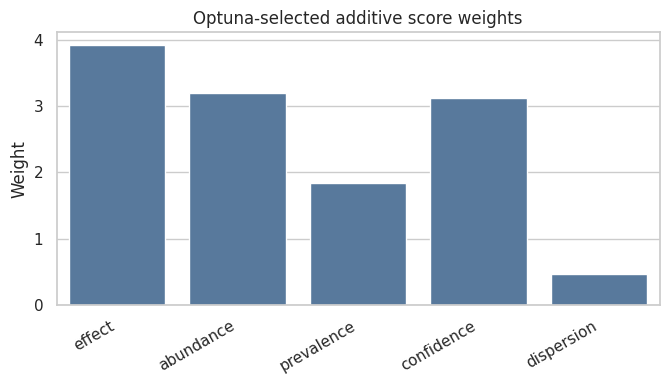

In [7]:
weight_df = pd.Series(best_weights.as_dict(), name="weight").reset_index().rename(columns={"index": "component"})

plt.figure(figsize=(7, 4))
sns.barplot(data=weight_df, x="component", y="weight", color="#4C78A8")
plt.title("Optuna-selected additive score weights")
plt.xlabel("")
plt.ylabel("Weight")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()


## Score Motifs With The Optimized Configuration

The final score is `stability_gate * additive_score`. The additive score contains effect size, abundance, prevalence, confidence, and dispersion desirability.


In [8]:
soft_result = score_soft_motifs_from_discriminator(
    discriminator=discriminator,
    config=selection_config,
)

scored_motifs_df = soft_result.scores
selected_motif_ids = soft_result.selected_motif_ids

display(scored_motifs_df.head(20))
selected_motif_ids


Estimating motif stability:   0%|          | 0/37 [00:00<?, ?it/s]

,ID,auc,effect_score,mean_group_0,mean_group_1,logfc_group1_vs_group0,abs_logfc,direction,mean_abundance,abundance_raw,...,dispersion,q_value,confidence_score,abundance_score,prevalence_score,dispersion_desirability_score,additive_score,stability,stability_gate,final_score
0,30006732,0.404762,0.190476,0.226416,0.127041,-0.833676,0.833676,Short-term survival,0.145842,0.136140,...,1.146529,0.763042,0.254899,1.000000,0.594595,0.936448,0.500204,0.891892,1.000000,0.500204
1,6077900,0.883333,0.766667,0.000000,0.000325,18.311720,18.311720,Long-term survival,0.000264,0.000264,...,2.372424,0.500422,0.537402,0.001935,0.621622,0.699919,0.491044,1.000000,1.000000,0.491044
2,6151628,0.790476,0.580952,0.000271,0.001190,2.134624,2.134624,Long-term survival,0.001016,0.001016,...,1.182861,0.500422,0.537402,0.007459,0.864865,0.929438,0.478957,1.000000,1.000000,0.478957
3,6053324,0.850000,0.700000,0.000007,0.000470,6.083482,6.083482,Long-term survival,0.000383,0.000383,...,3.275308,0.500422,0.537402,0.002808,0.675676,0.525712,0.471860,1.000000,1.000000,0.471860
4,31317452,0.288095,0.423810,0.092498,0.050896,-0.861873,0.861873,Short-term survival,0.058766,0.057105,...,0.817151,0.763042,0.254899,0.419454,0.891892,1.000000,0.471240,0.864865,1.000000,0.471240
5,12443084,0.776190,0.552381,0.000204,0.000993,2.284126,2.284126,Long-term survival,0.000844,0.000843,...,1.200992,0.500422,0.537402,0.006192,0.864865,0.925940,0.469592,0.945946,1.000000,0.469592
6,8202636,0.214286,0.571429,0.000023,0.000000,-14.493838,14.493838,Short-term survival,0.000004,0.000004,...,3.086521,0.070383,1.000000,0.000030,0.108108,0.562138,0.464025,0.864865,1.000000,0.464025
7,3964364,0.780952,0.561905,0.000039,0.000379,3.291799,3.291799,Long-term survival,0.000315,0.000315,...,1.492032,0.500422,0.537402,0.002311,0.702703,0.869785,0.445610,0.837838,1.000000,0.445610
8,4054476,0.752381,0.504762,0.000282,0.001005,1.831506,1.831506,Long-term survival,0.000868,0.000868,...,1.497320,0.500422,0.537402,0.006374,0.810811,0.868765,0.444685,0.783784,1.000000,0.444685
9,3955884,0.816667,0.633333,0.000000,0.000118,16.848939,16.848939,Long-term survival,0.000096,0.000096,...,1.988732,0.500422,0.537402,0.000701,0.513514,0.773950,0.436041,0.702703,1.000000,0.436041


[30006732,
 6077900,
 6151628,
 6053324,
 31317452,
 12443084,
 8202636,
 3964364,
 4054476,
 3955884]

/home/omriavit/.conda/envs/CISM/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/omriavit/.conda/envs/CISM/lib/python3.9/site-packages/seaborn/categorical.py:1271: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub_data
/home/omriavit/.conda/envs/CISM/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` inst

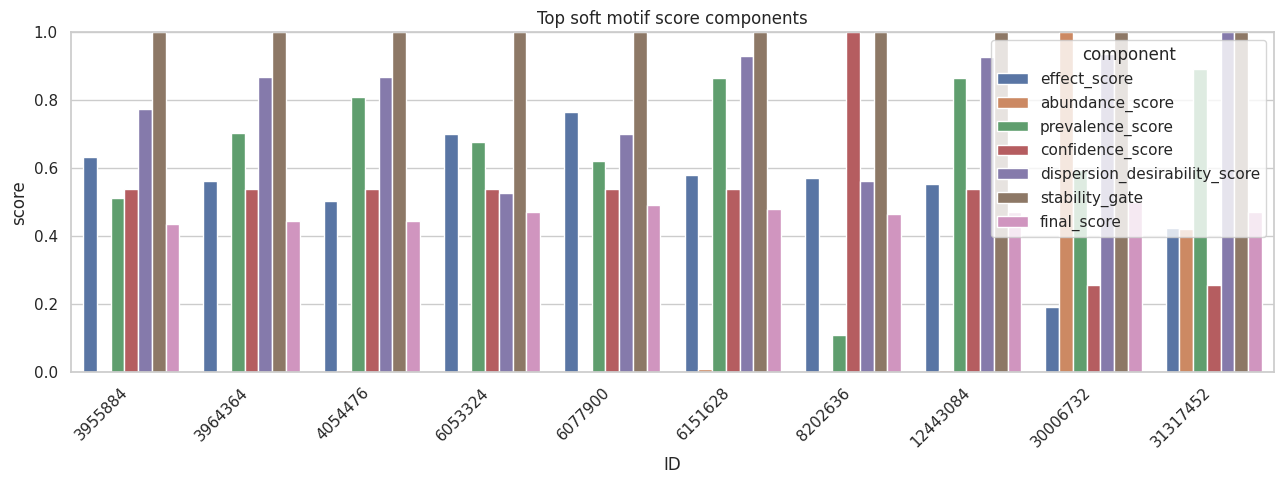

In [9]:
plot_columns = [
    "effect_score",
    "abundance_score",
    "prevalence_score",
    "confidence_score",
    "dispersion_desirability_score",
    "stability_gate",
    "final_score",
]

top_plot_df = scored_motifs_df.head(10).melt(
    id_vars="ID",
    value_vars=plot_columns,
    var_name="component",
    value_name="score",
)

plt.figure(figsize=(13, 5))
sns.barplot(data=top_plot_df, x="ID", y="score", hue="component")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.title("Top soft motif score components")
plt.tight_layout()


## Leakage-Safe LOOCV Validation

This validation re-selects motifs inside each training fold, trains a Random Forest on the selected motif frequencies, and tests only on the held-out patient.


In [10]:
loocv_result = evaluate_soft_motif_selection_loocv(
    discriminator=discriminator,
    config=selection_config,
    random_state=RANDOM_STATE,
    show_progress=True,
)

display(loocv_result.results)
print(f"ROC AUC: {loocv_result.get_roc_auc_score():.3f}")
loocv_result.get_metrics()


Evaluating soft motif LOOCV:   0%|          | 0/37 [00:00<?, ?it/s]

,TP,TN,FN,FP,cFeatures,prob,class,pred_class,classes,contributions,shape_values
TNBC1,0,1,0,0,10,"[[1.0, 0.0]]",Long-term survival,Long-term survival,"[Long-term survival, Short-term survival]",<zip object at 0x7f39a30f1200>,"(None, [30006732])"
TNBC10,0,1,0,0,10,"[[1.0, 0.0]]",Long-term survival,Long-term survival,"[Long-term survival, Short-term survival]",<zip object at 0x7f39a28fa100>,"(None, [30006732])"
TNBC11,0,1,0,0,10,"[[1.0, 0.0]]",Long-term survival,Long-term survival,"[Long-term survival, Short-term survival]",<zip object at 0x7f39a22854c0>,"(None, [30006732])"
TNBC12,0,1,0,0,10,"[[0.6627222222222222, 0.33727777777777773]]",Long-term survival,Long-term survival,"[Long-term survival, Short-term survival]",<zip object at 0x7f39a3ecf240>,"(None, [6077900])"
TNBC13,0,1,0,0,10,"[[1.0, 0.0]]",Long-term survival,Long-term survival,"[Long-term survival, Short-term survival]",<zip object at 0x7f39a2610540>,"(None, [30006732])"
TNBC14,0,1,0,0,10,"[[0.825, 0.175]]",Long-term survival,Long-term survival,"[Long-term survival, Short-term survival]",<zip object at 0x7f39a1be25c0>,"(None, [31317452])"
TNBC15,0,1,0,0,10,"[[0.5, 0.5]]",Long-term survival,Long-term survival,"[Long-term survival, Short-term survival]",<zip object at 0x7f39a2666380>,"(None, [31317452])"
TNBC16,0,0,1,0,10,"[[0.98, 0.02]]",Short-term survival,Long-term survival,"[Long-term survival, Short-term survival]",<zip object at 0x7f39a22c4dc0>,"(None, [31317452])"
TNBC17,0,1,0,0,10,"[[0.7002261904761903, 0.2997738095238094]]",Long-term survival,Long-term survival,"[Long-term survival, Short-term survival]",<zip object at 0x7f39a3d70740>,"(None, [6077900])"
TNBC18,0,1,0,0,10,"[[0.6233333333333333, 0.37666666666666665]]",Long-term survival,Long-term survival,"[Long-term survival, Short-term survival]",<zip object at 0x7f39a1b37340>,"(None, [31317452])"


ROC AUC: 0.788
recall: 0.2857142857142857
precision: 0.6666666666666666
accuracy: 0.8378378378378378
f1_score: 0.4


{'acc': np.float64(0.8378378378378378),
 'precision': np.float64(0.6666666666666666),
 'recall': np.float64(0.2857142857142857),
 'f1_score': np.float64(0.4)}

## Feature Importance

The validation result stores SHAP explanations for each held-out patient. We aggregate mean absolute SHAP values across folds to see which selected motifs most influenced Random Forest predictions.


In [12]:
def fold_shap_importance(row):
    shap_values, instance = row["shape_values"]
    values = np.asarray(shap_values.values)
    if values.ndim == 3:
        values = np.abs(values).mean(axis=(0, 2))
    elif values.ndim == 2:
        values = np.abs(values).mean(axis=0)
    else:
        values = np.abs(values).reshape(-1)
    return pd.Series(values, index=instance.columns, dtype=float)

importance_df = pd.DataFrame(
    [fold_shap_importance(row) for _, row in loocv_result.results.iterrows()]
).fillna(0.0)

feature_importance = importance_df.mean(axis=0).sort_values(ascending=False)
feature_importance_df = feature_importance.rename("mean_abs_shap").reset_index().rename(columns={"index": "ID"})
feature_importance_df["ID"] = feature_importance_df["ID"].astype(str)

display(feature_importance_df.head(20))

plt.figure(figsize=(9, 6))
sns.barplot(data=feature_importance_df.head(20), y="ID", x="mean_abs_shap", color="#59A14F")
plt.title("Random Forest motif feature importance")
plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Motif ID")
plt.tight_layout()


AttributeError: 'NoneType' object has no attribute 'values'

## Visualize The Top 3 Meaningful Motifs

Here, “meaningful” means the highest final-scoring motifs after stability gating. The table shows their score components before drawing their motif graphs.


,ID,final_score,additive_score,stability_gate,effect_score,overall_prevalence,direction,logfc_group1_vs_group0
0,30006732,0.500204,0.500204,1.0,0.190476,0.594595,Short-term survival,-0.833676
1,6077900,0.491044,0.491044,1.0,0.766667,0.621622,Long-term survival,18.311720
2,6151628,0.478957,0.478957,1.0,0.580952,0.864865,Long-term survival,2.134624


Drawing top motifs:   0%|          | 0/3 [00:00<?, ?it/s]

Motif 30006732: final=0.500, effect=0.190, direction=Short-term survival


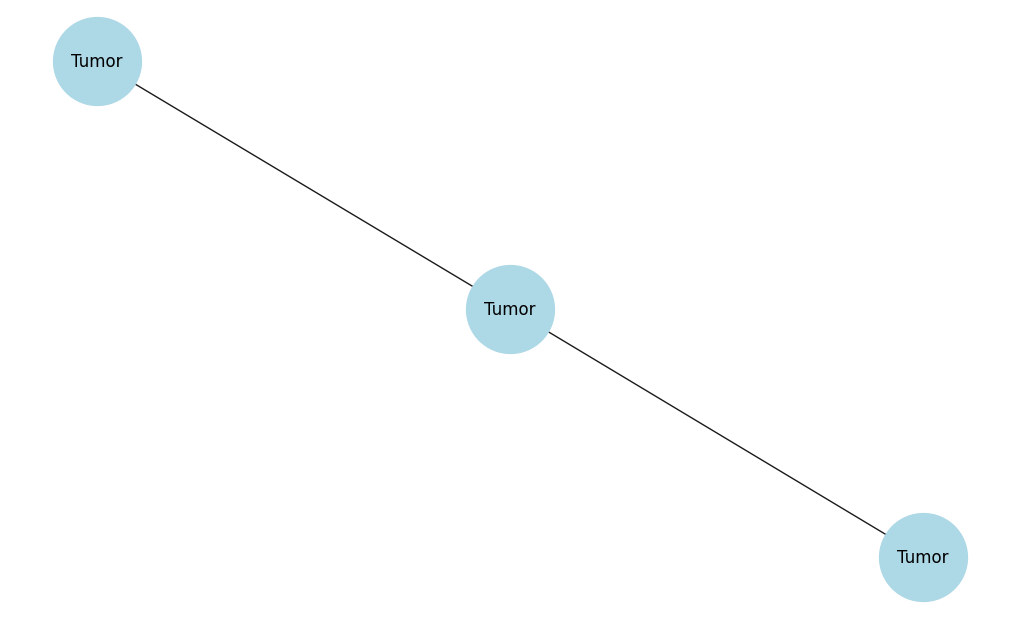

Motif 6077900: final=0.491, effect=0.767, direction=Long-term survival


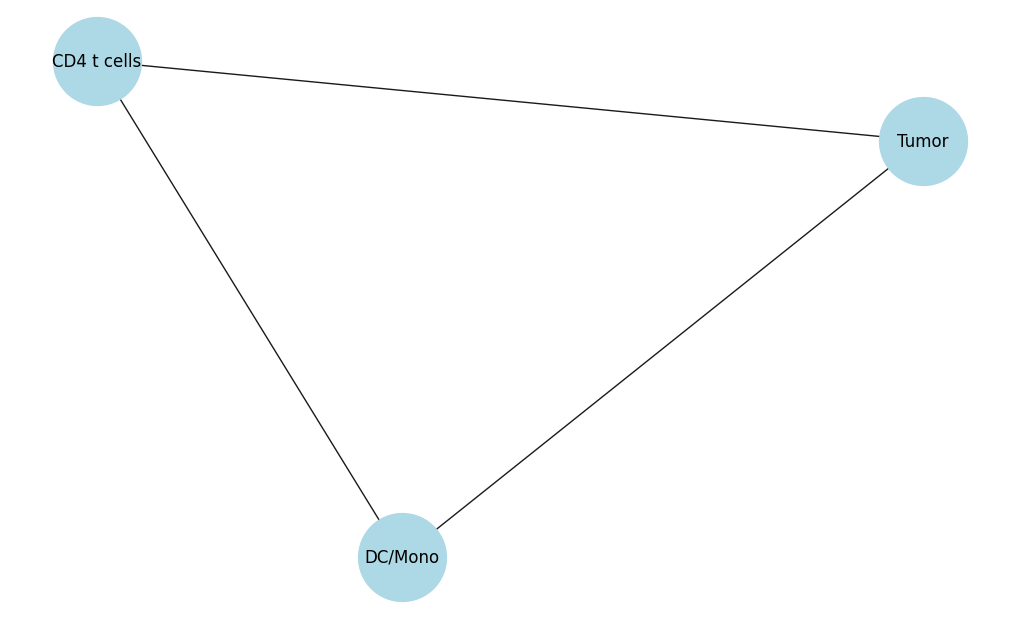

Motif 6151628: final=0.479, effect=0.581, direction=Long-term survival


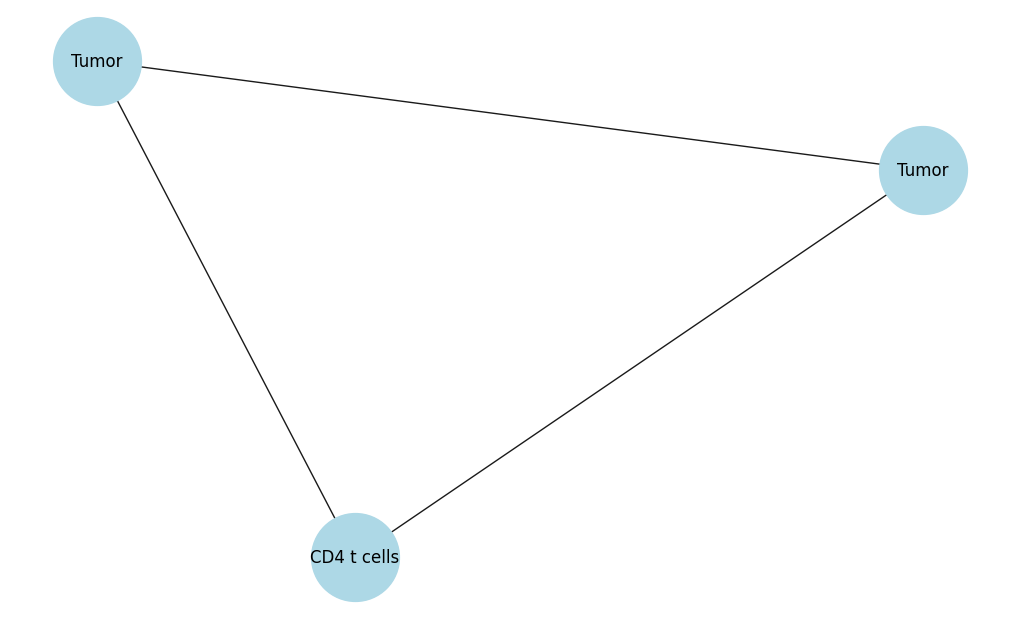

In [13]:
top3_motifs = scored_motifs_df.head(3).copy()
motif_lookup = (
    discriminator.cism.motifs_dataset
    .drop_duplicates("ID")
    .set_index("ID")["motif"]
)

display(top3_motifs[[
    "ID",
    "final_score",
    "additive_score",
    "stability_gate",
    "effect_score",
    "overall_prevalence",
    "direction",
    "logfc_group1_vs_group0",
]])

for _, motif_row in tqdm(top3_motifs.iterrows(), total=top3_motifs.shape[0], desc="Drawing top motifs"):
    motif_id = motif_row["ID"]
    print(
        f"Motif {motif_id}: final={motif_row['final_score']:.3f}, "
        f"effect={motif_row['effect_score']:.3f}, direction={motif_row['direction']}"
    )
    draw_motif(motif_lookup.loc[motif_id], common_cells_type)


## Reuse Selected Motifs With Existing CISM Analysis

`InferenceFC` is the bridge back into CISM's existing validation/inference API. It fixes the selected motif IDs instead of discovering a new motif set.


In [14]:
soft_inference_feature_conf = soft_result.to_inference_feature_config()

# Equivalent explicit construction:
# soft_inference_feature_conf = InferenceFC(labels=labels, motifs_ids=selected_motif_ids)

soft_inference_feature_conf


In [15]:
scored_motifs_path = SOFT_MOTIF_OUTPUT_ROOT / "soft_motif_scores.csv"
selected_motifs_path = SOFT_MOTIF_OUTPUT_ROOT / "selected_soft_motif_ids.csv"
optuna_trials_path = SOFT_MOTIF_OUTPUT_ROOT / "soft_motif_weight_optuna_trials.csv"

scored_motifs_df.to_csv(scored_motifs_path, index=False)
pd.Series(selected_motif_ids, name="ID").to_csv(selected_motifs_path, index=False)
weight_tuning_result.trials_dataframe().to_csv(optuna_trials_path, index=False)

print(f"Saved scored motifs: {scored_motifs_path}")
print(f"Saved selected motif IDs: {selected_motifs_path}")
print(f"Saved Optuna trials: {optuna_trials_path}")


Saved scored motifs: /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/soft_motif_selection/soft_motif_scores.csv
Saved selected motif IDs: /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/soft_motif_selection/selected_soft_motif_ids.csv
Saved Optuna trials: /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/soft_motif_selection/soft_motif_weight_optuna_trials.csv
